<h1 style="text-align:center;">Integrate experimental X-scan data with AF3 PAE</h1>

In [65]:
import json
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# Predict experimentally tested models

In [20]:
# predict experimentally tested models

dico = [
    {'id': 'TCR_YF1', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAVGDDKIIF', 'TRBV':'TRBV28', 'TRBJ':'TRBJ2-7', 'cdr3_TRB':'CASTPQTAYEQYF'},
    {'id': 'TCR_YF2', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAVNPDKIIF', 'TRBV':'TRBV4-2', 'TRBJ':'TRBJ1-4', 'cdr3_TRB':'CASSQEDRGPEKLFF'},
    {'id': 'TCR_YF3', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAAGDDKIIF', 'TRBV':'TRBV29-1', 'TRBJ':'TRBJ2-1', 'cdr3_TRB':'CSVATSGGSNEQFF'}
]

df = pd.DataFrame(dico)
df['peptide'] = 'LLWNGPMAV'
df['MHC'] = 'HLA_A0201'
df['species'] = 'HomoSapiens'

df.to_csv('Xscan_models.csv', index=False)
df

,id,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,peptide,MHC,species
0,TCR_YF1,TRAV12-2,TRAJ30,CAVGDDKIIF,TRBV28,TRBJ2-7,CASTPQTAYEQYF,LLWNGPMAV,HLA_A0201,HomoSapiens
1,TCR_YF2,TRAV12-2,TRAJ30,CAVNPDKIIF,TRBV4-2,TRBJ1-4,CASSQEDRGPEKLFF,LLWNGPMAV,HLA_A0201,HomoSapiens
2,TCR_YF3,TRAV12-2,TRAJ30,CAAGDDKIIF,TRBV29-1,TRBJ2-1,CSVATSGGSNEQFF,LLWNGPMAV,HLA_A0201,HomoSapiens


# Extract peptide PAE

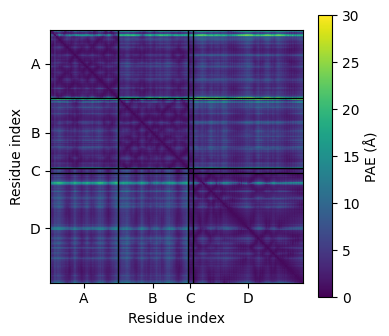

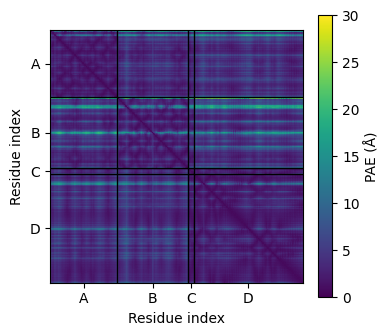

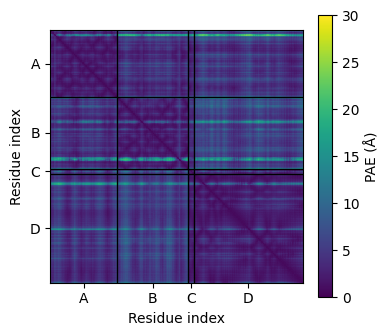

,pae_col,Position,TCR
0,3.294629,1,TCR_YF1
1,3.075765,2,TCR_YF1
2,2.969565,3,TCR_YF1
3,2.894388,4,TCR_YF1
4,2.879231,5,TCR_YF1
5,2.980612,6,TCR_YF1
6,3.036923,7,TCR_YF1
7,3.240967,8,TCR_YF1
8,3.453708,9,TCR_YF1
0,3.090649,1,TCR_YF2


In [62]:
plot = True

lst = []
for t in range(3):
    json_file = f"AF3_output/tcr_yf{t+1}/fold_tcr_yf{t+1}_full_data_0.json"

    with open(json_file, "r") as f:
        data = json.load(f)

    # --- PAE ---
    pae = np.array(data["pae"])

    # --- Find per-residue chain IDs ---
    chain_ids = data["token_chain_ids"]
    chain_ids = np.array(chain_ids)

    # --- Reduce MHC to interface region ---
    mhc_chain = "D" 
    # keep all non-D chains
    idx_not_mhc = np.where(chain_ids != mhc_chain)[0]

    # keep only residues 26–200 of chain D
    idx_mhc = np.where(chain_ids == mhc_chain)[0]
    pos_in_mhc = np.arange(1, len(idx_mhc) + 1)   # 1-based numbering within chain D
    idx_mhc_keep = idx_mhc[(pos_in_mhc >= 26) & (pos_in_mhc <= 200)]

    # combine and sort
    idx_keep = np.sort(np.concatenate([idx_not_mhc, idx_mhc_keep]))

    # filter PAE and chain IDs
    pae = pae[np.ix_(idx_keep, idx_keep)]
    chain_ids = chain_ids[idx_keep]


    # --- Find chain boundaries ---
    boundaries = []
    chain_labels = []
    start = 0

    for i in range(1, len(chain_ids)):
        if chain_ids[i] != chain_ids[i - 1]:
            boundaries.append(i)
            chain_labels.append((start, i, chain_ids[i - 1]))
            start = i
    chain_labels.append((start, len(chain_ids), chain_ids[-1]))

    # --- Plot ---
    if plot:
        plt.figure(figsize=(4, 3.5))
        im = plt.imshow(pae, origin="upper", interpolation="nearest", vmin=0, vmax=30)
        plt.colorbar(im, label="PAE (Å)")
        plt.xlabel("Residue index")
        plt.ylabel("Residue index")

        # boundary lines
        for b in boundaries:
            plt.axhline(b - 0.5, linewidth=1, color='black')
            plt.axvline(b - 0.5, linewidth=1, color='black')

        # optional chain labels at segment centers
        tick_positions = []
        tick_labels = []
        for s, e, cid in chain_labels:
            tick_positions.append((s + e - 1) / 2)
            tick_labels.append(str(cid))

        plt.xticks(tick_positions, tick_labels)
        plt.yticks(tick_positions, tick_labels)

        plt.tight_layout()
        plt.show()

    # --- Extract peptide arrays ---
    peptide_chain = "C"
    idx_pep = np.where(chain_ids == peptide_chain)[0]

    col_pep = pae[:, idx_pep]
    col_pep[col_pep > 10] = np.nan
    
    df = pd.DataFrame()
    df['pae_col'] = np.nanmean(col_pep, axis=0)
    df['Position'] = np.arange(len(df)) +1
    
    df['TCR'] = f'TCR_YF{t+1}'
    lst.append(df)

df = pd.concat(lst)
df.to_pickle('mean_pae.pkl')
df

ActivationScore: Spearman rho = 0.73, p = 0.0246
ActivationScore: Spearman rho = 0.68, p = 0.0424
ActivationScore: Spearman rho = 0.65, p = 0.0581


Text(0, 0.5, 'TCR Activation [%]')

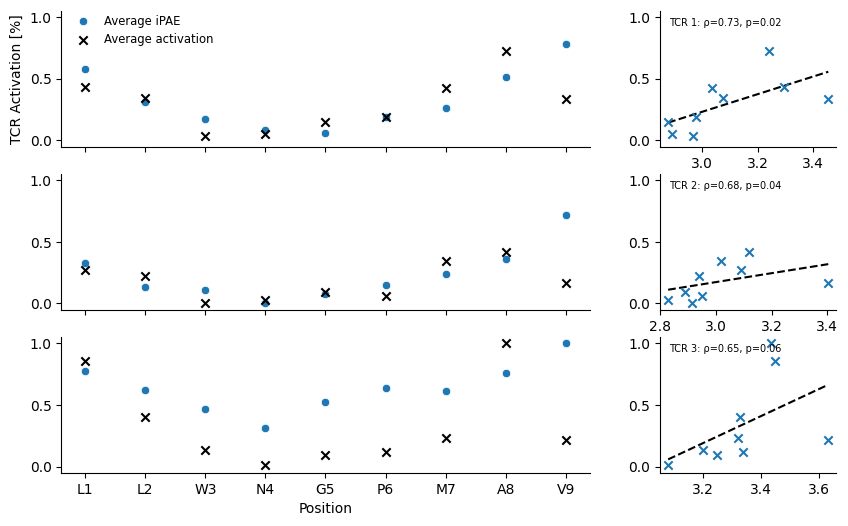

In [90]:
sequence = 'LLWNGPMAV'
df_activation = pd.read_pickle('../260317_YF-modes_exp_integration_clean/activation_scores.pkl')[['Position', 'TCR', 'ActivationScore']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position', 'TCR'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)


df_pae = pd.read_pickle('mean_pae.pkl')
col = df_pae['pae_col']
df_pae['pae_col_scaled'] = (col - col.min()) / (col.max() - col.min()) # scale between 0 and 1

df = pd.merge(df_activation, df_pae, on=['Position', 'TCR'])

fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharey=False, gridspec_kw={'width_ratios': [3, 1]})

for i in range(3):
    tmp = df[df['TCR'] == f'TCR_YF{i+1}']

    # scatter plot
    ax = axes[i][0]
    sns.scatterplot(data=tmp, x='Position', y='pae_col_scaled', ax=ax, label='Average iPAE')
    sns.scatterplot(data=tmp, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)
    ax.legend([], [], frameon=False)
    ax.set_ylabel(f'TCR {i+1} [%]')
    ax.set_ylim(-0.05,1.05)
    ax.set_xticklabels('')
    ax.set_ylabel('')

    # correlation plot
    ax = axes[i][1]

    # Compute Spearman correlation
    tmp = tmp.dropna()
    rho, pval = spearmanr(tmp['pae_col'], tmp['ActivationScore'])
    print(f"ActivationScore: Spearman rho = {rho:.2f}, p = {pval:.3g}")

    # Draw a smooth line showing monotonic trend
    sns.regplot(x=tmp['pae_col'], y=tmp['ActivationScore'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

    # Add rho to the plot
    # Format string
    if pval < 0.01:
        p_str = f"{pval:.1e}"   # scientific notation
    else:
        p_str = f"{pval:.2f}"   # fixed-point

    ax.text(
    0.05, 0.95, f"TCR {i+1}: ρ={rho:.2f}, p={p_str}", 
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
    )

    df_avg = (tmp.groupby(['Position', 'pae_col'], as_index=False)['ActivationScore'].mean())
    sns.scatterplot(df_avg, x='pae_col', y='ActivationScore', ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.05,1.05)
    sns.despine()



axes[0][0].legend(bbox_to_anchor=(0,1.05), frameon=False, title='', loc='upper left', fontsize='small')

sequence = 'LLWNGPMAV'
new_labels = [f'{sequence[i]}{i+1}' for i in range(9)]
axes[2][0].set_xticks(range(1, len(new_labels)+1))
axes[2][0].set_xticklabels(new_labels)

axes[0][0].set_xlabel('')
axes[1][0].set_xlabel('')
axes[2][0].set_xlabel('Position')

axes[0][0].set_ylabel('TCR Activation [%]')

